In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

def deg(theta_deg):
    return np.deg2rad(theta_deg)

def clean_array(A, tol=1e-12):
    A = np.array(A, dtype=complex)
    A[np.abs(A.real) < tol] = 1j * A[np.abs(A.real) < tol].imag
    A[np.abs(A.imag) < tol] = A[np.abs(A.imag) < tol].real
    return A

def print_matrix(name, M):
    M = clean_array(M)
    print(f"{name} =")
    print(M)
    print()

def intensity(P):
    P = np.array(P, dtype=complex)
    return np.vdot(P, P).real

# Vektor Jones dasar
P_H = np.array([[1], [0]], dtype=complex)
P_V = np.array([[0], [1]], dtype=complex)

P_plus_45 = (1 / np.sqrt(2)) * np.array([[1], [1]], dtype=complex)
P_minus_45 = (1 / np.sqrt(2)) * np.array([[1], [-1]], dtype=complex)

P_L = (1 / np.sqrt(2)) * np.array([[1], [1j]], dtype=complex)
P_R = (1 / np.sqrt(2)) * np.array([[1], [-1j]], dtype=complex)

def P_theta(theta_deg):
    theta = deg(theta_deg)
    return np.array([[np.cos(theta)], [np.sin(theta)]], dtype=complex)

# Matriks Jones dasar
J_H = np.array([[1, 0], [0, 0]], dtype=complex)
J_V = np.array([[0, 0], [0, 1]], dtype=complex)

def J_linear_polarizer(theta_deg):
    theta = deg(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c**2, c*s],
        [c*s, s**2]
    ], dtype=complex)

def J_half_wave_plate(theta_deg):
    theta = deg(theta_deg)
    return np.array([
        [np.cos(2 * theta), np.sin(2 * theta)],
        [np.sin(2 * theta), -np.cos(2 * theta)]
    ], dtype=complex)

def J_quarter_wave_plate(theta_deg):
    theta = deg(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c**2 + 1j * s**2, (1 - 1j) * s * c],
        [(1 - 1j) * s * c, s**2 + 1j * c**2]
    ], dtype=complex)

def J_quarter_wave_plate_pm45(angle_deg):
    if angle_deg == 45:
        return (1 / np.sqrt(2)) * np.array([
            [1, -1j],
            [-1j, 1]
        ], dtype=complex)
    elif angle_deg == -45:
        return (1 / np.sqrt(2)) * np.array([
            [1, 1j],
            [1j, 1]
        ], dtype=complex)
    else:
        raise ValueError("Gunakan angle_deg = 45 atau angle_deg = -45.")

# Vektor Jones untuk Polarisasi Dasar

Dalam kalkulus Jones, polarisasi horizontal dan vertikal direpresentasikan oleh vektor kolom

$$
\vec{P}_H =
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\vec{P}_V =
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Polarisasi linier dengan sudut $\theta$ terhadap horizontal ditulis sebagai

$$
\vec{P}_{\theta}
=
\begin{bmatrix}
\cos\theta\\
\sin\theta
\end{bmatrix}.
$$

Beberapa vektor Jones yang sering digunakan adalah

$$
\vec{P}_{+45}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
1
\end{bmatrix},
\qquad
\vec{P}_{-45}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1
\end{bmatrix},
$$

$$
\vec{P}_L
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
i
\end{bmatrix},
\qquad
\vec{P}_R
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-i
\end{bmatrix}.
$$

In [2]:
print_matrix("P_H", P_H)
print_matrix("P_V", P_V)
print_matrix("P_+45", P_plus_45)
print_matrix("P_-45", P_minus_45)
print_matrix("P_L", P_L)
print_matrix("P_R", P_R)

theta = 30
P_30 = P_theta(theta)
print_matrix(f"P_theta untuk theta = {theta} derajat", P_30)

print("Norma atau intensitas relatif setiap vektor Jones:")
print("I(P_H)     =", intensity(P_H))
print("I(P_V)     =", intensity(P_V))
print("I(P_+45)   =", intensity(P_plus_45))
print("I(P_-45)   =", intensity(P_minus_45))
print("I(P_L)     =", intensity(P_L))
print("I(P_R)     =", intensity(P_R))
print("I(P_30)    =", intensity(P_30))

P_H =
[[1.+0.j]
 [0.+0.j]]

P_V =
[[0.+0.j]
 [1.+0.j]]

P_+45 =
[[0.7071+0.j]
 [0.7071+0.j]]

P_-45 =
[[ 0.7071+0.j]
 [-0.7071+0.j]]

P_L =
[[0.7071+0.j    ]
 [0.    +0.7071j]]

P_R =
[[ 0.7071+0.j    ]
 [-0.    -0.7071j]]

P_theta untuk theta = 30 derajat =
[[0.866+0.j]
 [0.5  +0.j]]

Norma atau intensitas relatif setiap vektor Jones:
I(P_H)     = 1.0
I(P_V)     = 1.0
I(P_+45)   = 0.9999999999999998
I(P_-45)   = 0.9999999999999998
I(P_L)     = 0.9999999999999998
I(P_R)     = 0.9999999999999998
I(P_30)    = 1.0


# Pelat Setengah Gelombang pada Polarisasi Horizontal

Matriks Jones untuk pelat setengah gelombang dengan sumbu cepat membentuk sudut $\theta$ terhadap horizontal adalah

$$
\mathbf{J}_{\lambda/2,\theta}
=
\begin{bmatrix}
\cos 2\theta & \sin 2\theta\\
\sin 2\theta & -\cos 2\theta
\end{bmatrix}.
$$

Jika cahaya datang terpolarisasi horizontal,

$$
\vec{P}_H
=
\begin{bmatrix}
1\\
0
\end{bmatrix},
$$

maka polarisasi keluaran adalah

$$
\vec{P}_{\text{out}}
=
\mathbf{J}_{\lambda/2,\theta}\vec{P}_H.
$$

Secara langsung,

$$
\vec{P}_{\text{out}}
=
\begin{bmatrix}
\cos 2\theta & \sin 2\theta\\
\sin 2\theta & -\cos 2\theta
\end{bmatrix}
\begin{bmatrix}
1\\
0
\end{bmatrix}
=
\begin{bmatrix}
\cos 2\theta\\
\sin 2\theta
\end{bmatrix}.
$$

Jadi, pelat setengah gelombang merotasi polarisasi horizontal menjadi polarisasi linier dengan sudut $2\theta$ terhadap horizontal.

In [3]:
theta = 30

J = J_half_wave_plate(theta)
P_out = J @ P_H

print_matrix(f"J_lambda/2 untuk theta = {theta} derajat", J)
print_matrix("P_H", P_H)
print_matrix("P_out = J_lambda/2 P_H", P_out)

expected = P_theta(2 * theta)
print_matrix(f"P_theta dengan sudut 2 theta = {2 * theta} derajat", expected)

print("Apakah P_out sama dengan P_{2 theta}?")
print(np.allclose(P_out, expected))

J_lambda/2 untuk theta = 30 derajat =
[[ 0.5  +0.j  0.866+0.j]
 [ 0.866+0.j -0.5  +0.j]]

P_H =
[[1.+0.j]
 [0.+0.j]]

P_out = J_lambda/2 P_H =
[[0.5  +0.j]
 [0.866+0.j]]

P_theta dengan sudut 2 theta = 60 derajat =
[[0.5  +0.j]
 [0.866+0.j]]

Apakah P_out sama dengan P_{2 theta}?
True


# Keluaran Polarisator Linier $+45^\circ$ untuk Masukan Vertikal

Matriks Jones polarisator linier dengan sumbu transmisi pada sudut $\theta$ terhadap horizontal adalah

$$
\mathbf{J}_{\theta}
=
\begin{bmatrix}
\cos^2\theta & \cos\theta\sin\theta\\
\cos\theta\sin\theta & \sin^2\theta
\end{bmatrix}.
$$

Untuk $\theta = 45^\circ$,

$$
\mathbf{J}_{+45}
=
\frac{1}{2}
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}.
$$

Jika cahaya datang terpolarisasi vertikal,

$$
\vec{P}_V
=
\begin{bmatrix}
0\\
1
\end{bmatrix},
$$

maka

$$
\vec{P}_{\text{out}}
=
\mathbf{J}_{+45}\vec{P}_V
=
\frac{1}{2}
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\frac{1}{2}
\begin{bmatrix}
1\\
1
\end{bmatrix}.
$$

Karena

$$
\vec{P}_{+45}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
1
\end{bmatrix},
$$

maka

$$
\vec{P}_{\text{out}}
=
\frac{1}{\sqrt{2}}\vec{P}_{+45}.
$$

Faktor $1/\sqrt{2}$ mengurangi amplitudo medan listrik. Intensitas berkurang dengan faktor

$$
\left(\frac{1}{\sqrt{2}}\right)^2 = \frac{1}{2}.
$$

In [4]:
J_45 = J_linear_polarizer(45)
P_out = J_45 @ P_V

print_matrix("J_+45", J_45)
print_matrix("P_V", P_V)
print_matrix("P_out = J_+45 P_V", P_out)

amplitude_factor = np.sqrt(intensity(P_out) / intensity(P_plus_45))
intensity_factor = intensity(P_out) / intensity(P_V)

print("Faktor amplitudo relatif terhadap P_+45 =", amplitude_factor)
print("Faktor intensitas terhadap masukan       =", intensity_factor)

print()
print("Apakah P_out = (1/sqrt(2)) P_+45?")
print(np.allclose(P_out, (1 / np.sqrt(2)) * P_plus_45))

J_+45 =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

P_V =
[[0.+0.j]
 [1.+0.j]]

P_out = J_+45 P_V =
[[0.5+0.j]
 [0.5+0.j]]

Faktor amplitudo relatif terhadap P_+45 = 0.7071067811865476
Faktor intensitas terhadap masukan       = 0.4999999999999999

Apakah P_out = (1/sqrt(2)) P_+45?
True


# Pelat Setengah Gelombang Mengubah Polarisasi Melingkar Kanan menjadi Melingkar Kiri

Vektor Jones untuk polarisasi melingkar kanan adalah

$$
\vec{P}_R
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-i
\end{bmatrix}.
$$

Vektor Jones untuk polarisasi melingkar kiri adalah

$$
\vec{P}_L
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
i
\end{bmatrix}.
$$

Untuk pelat setengah gelombang,

$$
\mathbf{J}_{\lambda/2,\theta}
=
\begin{bmatrix}
\cos 2\theta & \sin 2\theta\\
\sin 2\theta & -\cos 2\theta
\end{bmatrix}.
$$

Keluaran untuk masukan $\vec{P}_R$ adalah

$$
\mathbf{J}_{\lambda/2,\theta}\vec{P}_R
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
\cos 2\theta - i\sin 2\theta\\
\sin 2\theta + i\cos 2\theta
\end{bmatrix}.
$$

Dengan identitas Euler,

$$
\cos 2\theta - i\sin 2\theta = e^{-i2\theta},
$$

maka

$$
\mathbf{J}_{\lambda/2,\theta}\vec{P}_R
=
e^{-i2\theta}
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
i
\end{bmatrix}
=
e^{-i2\theta}\vec{P}_L.
$$

Jadi, polarisasi melingkar kanan berubah menjadi polarisasi melingkar kiri, dengan faktor fase global $e^{-i2\theta}$.

In [5]:
theta = 27

J = J_half_wave_plate(theta)
P_out = J @ P_R
phase_factor = np.exp(-1j * 2 * deg(theta))
expected = phase_factor * P_L

print_matrix(f"J_lambda/2 untuk theta = {theta} derajat", J)
print_matrix("P_R", P_R)
print_matrix("P_out = J_lambda/2 P_R", P_out)
print_matrix("e^{-i 2 theta} P_L", expected)

print("Apakah P_out = e^{-i 2 theta} P_L?")
print(np.allclose(P_out, expected))

print()
print("Intensitas masukan  =", intensity(P_R))
print("Intensitas keluaran =", intensity(P_out))

J_lambda/2 untuk theta = 27 derajat =
[[ 0.5878+0.j  0.809 +0.j]
 [ 0.809 +0.j -0.5878+0.j]]

P_R =
[[ 0.7071+0.j    ]
 [-0.    -0.7071j]]

P_out = J_lambda/2 P_R =
[[0.4156-0.5721j]
 [0.5721+0.4156j]]

e^{-i 2 theta} P_L =
[[0.4156-0.5721j]
 [0.5721+0.4156j]]

Apakah P_out = e^{-i 2 theta} P_L?
True

Intensitas masukan  = 0.9999999999999998
Intensitas keluaran = 0.9999999999999999


# Urutan Operasi Matriks Jones

Misalkan cahaya melewati dua elemen optik secara berurutan:

1. Pelat setengah gelombang dengan sudut $\theta = 45^\circ$.
2. Polarisator horizontal.

Karena elemen pertama bekerja langsung pada vektor masukan, matriks elemen pertama ditulis paling dekat dengan vektor masukan. Jadi matriks efektifnya adalah

$$
\mathbf{J}_{\text{eff}}
=
\mathbf{J}_H\mathbf{J}_{\lambda/2,45}.
$$

Untuk $\theta = 45^\circ$,

$$
\mathbf{J}_{\lambda/2,45}
=
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix},
$$

sehingga

$$
\mathbf{J}_H\mathbf{J}_{\lambda/2,45}
=
\begin{bmatrix}
1 & 0\\
0 & 0
\end{bmatrix}
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & 1\\
0 & 0
\end{bmatrix}.
$$

Jika urutannya dibalik,

$$
\mathbf{J}_{\lambda/2,45}\mathbf{J}_H
=
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
\begin{bmatrix}
1 & 0\\
0 & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & 0\\
1 & 0
\end{bmatrix}.
$$

Dua hasil tersebut berbeda. Jadi, urutan elemen optik memengaruhi hasil akhir.

In [6]:
J_hwp_45 = J_half_wave_plate(45)

A = J_H @ J_hwp_45
B = J_hwp_45 @ J_H

print_matrix("J_H", J_H)
print_matrix("J_lambda/2,45", J_hwp_45)

print_matrix("J_H J_lambda/2,45", A)
print_matrix("J_lambda/2,45 J_H", B)

print("Apakah kedua matriks sama?")
print(np.allclose(A, B))

P_in = P_H

P_out_A = A @ P_in
P_out_B = B @ P_in

print()
print_matrix("Keluaran untuk urutan J_H J_lambda/2,45 dengan masukan P_H", P_out_A)
print_matrix("Keluaran untuk urutan J_lambda/2,45 J_H dengan masukan P_H", P_out_B)

J_H =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

J_lambda/2,45 =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

J_H J_lambda/2,45 =
[[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

J_lambda/2,45 J_H =
[[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]

Apakah kedua matriks sama?
False

Keluaran untuk urutan J_H J_lambda/2,45 dengan masukan P_H =
[[0.+0.j]
 [0.+0.j]]

Keluaran untuk urutan J_lambda/2,45 J_H dengan masukan P_H =
[[0.+0.j]
 [1.+0.j]]



# Matriks Jones Efektif dari Tiga Elemen Optik

Sistem optik terdiri atas tiga elemen berurutan:

1. Pelat setengah gelombang dengan sumbu cepat pada sudut $+22.5^\circ$.
2. Pelat seperempat gelombang dengan sumbu cepat sejajar vertikal.
3. Pelat seperempat gelombang dengan sumbu cepat pada sudut $+45^\circ$.

Karena elemen pertama bekerja lebih dahulu, matriks efektifnya adalah

$$
\mathbf{J}
=
\mathbf{J}_3\mathbf{J}_2\mathbf{J}_1.
$$

Dari catatan,

$$
\mathbf{J}_1
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1\\
1 & -1
\end{bmatrix},
$$

$$
\mathbf{J}_2
=
\begin{bmatrix}
i & 0\\
0 & 1
\end{bmatrix},
$$

dan

$$
\mathbf{J}_3
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & -i\\
-i & 1
\end{bmatrix}.
$$

Matriks efektifnya adalah

$$
\mathbf{J}
=
\mathbf{J}_3\mathbf{J}_2\mathbf{J}_1
=
\begin{bmatrix}
0 & i\\
1 & 0
\end{bmatrix}.
$$

Jika cahaya datang terpolarisasi horizontal,

$$
\vec{P}_0
=
\begin{bmatrix}
1\\
0
\end{bmatrix},
$$

maka

$$
\vec{P}_3
=
\mathbf{J}\vec{P}_0
=
\begin{bmatrix}
0 & i\\
1 & 0
\end{bmatrix}
\begin{bmatrix}
1\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Jadi, keluarannya adalah polarisasi vertikal.

In [7]:
J1 = J_half_wave_plate(22.5)
J2 = J_quarter_wave_plate(90)
J3 = J_quarter_wave_plate_pm45(45)

J_eff = J3 @ J2 @ J1
P_out = J_eff @ P_H

print_matrix("J1 = J_lambda/2,22.5", J1)
print_matrix("J2 = J_lambda/4,90", J2)
print_matrix("J3 = J_lambda/4,+45", J3)
print_matrix("J_eff = J3 J2 J1", J_eff)

print_matrix("P_H", P_H)
print_matrix("P_out = J_eff P_H", P_out)

print("Apakah keluaran sama dengan P_V?")
print(np.allclose(P_out, P_V))

J1 = J_lambda/2,22.5 =
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

J2 = J_lambda/4,90 =
[[ 0.+1.j -0.+0.j]
 [-0.+0.j  1.+0.j]]

J3 = J_lambda/4,+45 =
[[ 0.7071+0.j     -0.    -0.7071j]
 [-0.    -0.7071j  0.7071+0.j    ]]

J_eff = J3 J2 J1 =
[[0.+0.j 0.+1.j]
 [1.+0.j 0.+0.j]]

P_H =
[[1.+0.j]
 [0.+0.j]]

P_out = J_eff P_H =
[[0.+0.j]
 [1.+0.j]]

Apakah keluaran sama dengan P_V?
True


# Latihan 1: Sistem Pelat Setengah Gelombang, Polarisator Horizontal, Pelat Setengah Gelombang

Tinjau sistem optik yang terdiri atas tiga elemen berurutan:

1. Pelat setengah gelombang dengan sumbu cepat membentuk sudut $\theta_1$ dari horizontal.
2. Polarisator horizontal.
3. Pelat setengah gelombang dengan sumbu cepat membentuk sudut $\theta_2$ dari horizontal.

Tentukan matriks Jones efektifnya.

Karena urutan operasi dibaca dari kanan ke kiri, matriks efektifnya adalah

$$
\mathbf{J}_{\text{eff}}
=
\mathbf{J}_{\lambda/2,\theta_2}
\mathbf{J}_H
\mathbf{J}_{\lambda/2,\theta_1}.
$$

Dengan

$$
\mathbf{J}_{\lambda/2,\theta_k}
=
\begin{bmatrix}
\cos 2\theta_k & \sin 2\theta_k\\
\sin 2\theta_k & -\cos 2\theta_k
\end{bmatrix},
$$

dan

$$
\mathbf{J}_H
=
\begin{bmatrix}
1 & 0\\
0 & 0
\end{bmatrix}.
$$

Maka

$$
\mathbf{J}_H\mathbf{J}_{\lambda/2,\theta_1}
=
\begin{bmatrix}
\cos 2\theta_1 & \sin 2\theta_1\\
0 & 0
\end{bmatrix}.
$$

Selanjutnya,

$$
\mathbf{J}_{\text{eff}}
=
\begin{bmatrix}
\cos 2\theta_2 & \sin 2\theta_2\\
\sin 2\theta_2 & -\cos 2\theta_2
\end{bmatrix}
\begin{bmatrix}
\cos 2\theta_1 & \sin 2\theta_1\\
0 & 0
\end{bmatrix}.
$$

Hasilnya adalah

$$
\mathbf{J}_{\text{eff}}
=
\begin{bmatrix}
\cos 2\theta_2\cos 2\theta_1 &
\cos 2\theta_2\sin 2\theta_1\\
\sin 2\theta_2\cos 2\theta_1 &
\sin 2\theta_2\sin 2\theta_1
\end{bmatrix}.
$$

Agar matriks ini ekuivalen dengan polarisator linier sudut $\theta$,

$$
\mathbf{J}_{\theta}
=
\begin{bmatrix}
\cos^2\theta & \sin\theta\cos\theta\\
\sin\theta\cos\theta & \sin^2\theta
\end{bmatrix},
$$

elemen luar diagonal harus simetris. Syaratnya adalah

$$
\cos 2\theta_2\sin 2\theta_1
=
\sin 2\theta_2\cos 2\theta_1.
$$

Maka

$$
\sin(2\theta_1 - 2\theta_2) = 0.
$$

Salah satu kondisi yang memenuhi adalah

$$
\theta_1 = \theta_2.
$$

Secara khusus, agar sistem ekuivalen dengan polarisator linier bersudut $\theta$ terhadap horizontal, ambil

$$
\theta_1 = \theta_2 = \frac{\theta}{2}.
$$

Matriks Jones efektif:


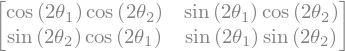

Elemen (1,2) dikurangi elemen (2,1):


Bentuk trigonometri syarat simetri:


In [8]:
theta1, theta2 = sp.symbols("theta_1 theta_2", real=True)

JH_sp = sp.Matrix([[1, 0], [0, 0]])

def HWP_sp(theta):
    return sp.Matrix([
        [sp.cos(2 * theta), sp.sin(2 * theta)],
        [sp.sin(2 * theta), -sp.cos(2 * theta)]
    ])

J_eff_sp = HWP_sp(theta2) * JH_sp * HWP_sp(theta1)
J_eff_sp = sp.simplify(J_eff_sp)

print("Matriks Jones efektif:")
display(J_eff_sp)

print("Elemen (1,2) dikurangi elemen (2,1):")
condition = sp.simplify(J_eff_sp[0, 1] - J_eff_sp[1, 0])
display(condition)

print("Bentuk trigonometri syarat simetri:")
display(sp.trigsimp(condition))

In [9]:
# Contoh numerik untuk Latihan 1
# Ambil theta_1 = theta_2 = theta/2 sehingga sistem ekuivalen dengan polarisator linier sudut theta.

theta = 60
theta1_num = theta / 2
theta2_num = theta / 2

J_eff_num = J_half_wave_plate(theta2_num) @ J_H @ J_half_wave_plate(theta1_num)
J_theta_num = J_linear_polarizer(theta)

print_matrix(f"J_eff untuk theta_1 = theta_2 = {theta/2} derajat", J_eff_num)
print_matrix(f"J_theta untuk theta = {theta} derajat", J_theta_num)

print("Apakah J_eff sama dengan J_theta?")
print(np.allclose(J_eff_num, J_theta_num))

J_eff untuk theta_1 = theta_2 = 30.0 derajat =
[[0.25 +0.j 0.433+0.j]
 [0.433+0.j 0.75 +0.j]]

J_theta untuk theta = 60 derajat =
[[0.25 +0.j 0.433+0.j]
 [0.433+0.j 0.75 +0.j]]

Apakah J_eff sama dengan J_theta?
True


# Latihan 2: Sistem Pelat Setengah Gelombang, Polarisator Vertikal, Pelat Setengah Gelombang

Tinjau sistem optik yang terdiri atas tiga elemen berurutan:

1. Pelat setengah gelombang dengan sumbu cepat membentuk sudut $\theta_1$ dari horizontal.
2. Polarisator vertikal.
3. Pelat setengah gelombang dengan sumbu cepat membentuk sudut $\theta_2$ dari horizontal.

Matriks efektifnya adalah

$$
\mathbf{J}_{\text{eff}}
=
\mathbf{J}_{\lambda/2,\theta_2}
\mathbf{J}_V
\mathbf{J}_{\lambda/2,\theta_1}.
$$

Dengan

$$
\mathbf{J}_V
=
\begin{bmatrix}
0 & 0\\
0 & 1
\end{bmatrix}.
$$

Pertama,

$$
\mathbf{J}_V\mathbf{J}_{\lambda/2,\theta_1}
=
\begin{bmatrix}
0 & 0\\
\sin 2\theta_1 & -\cos 2\theta_1
\end{bmatrix}.
$$

Kemudian,

$$
\mathbf{J}_{\text{eff}}
=
\begin{bmatrix}
\cos 2\theta_2 & \sin 2\theta_2\\
\sin 2\theta_2 & -\cos 2\theta_2
\end{bmatrix}
\begin{bmatrix}
0 & 0\\
\sin 2\theta_1 & -\cos 2\theta_1
\end{bmatrix}.
$$

Hasilnya adalah

$$
\mathbf{J}_{\text{eff}}
=
\begin{bmatrix}
\sin 2\theta_2\sin 2\theta_1 &
-\sin 2\theta_2\cos 2\theta_1\\
-\cos 2\theta_2\sin 2\theta_1 &
\cos 2\theta_2\cos 2\theta_1
\end{bmatrix}.
$$

Matriks Jones efektif untuk sistem dengan polarisator vertikal:


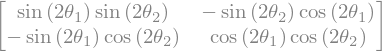

In [10]:
theta1, theta2 = sp.symbols("theta_1 theta_2", real=True)

JV_sp = sp.Matrix([[0, 0], [0, 1]])

J_eff_vertical_sp = HWP_sp(theta2) * JV_sp * HWP_sp(theta1)
J_eff_vertical_sp = sp.simplify(J_eff_vertical_sp)

print("Matriks Jones efektif untuk sistem dengan polarisator vertikal:")
display(J_eff_vertical_sp)

In [11]:
# Contoh numerik untuk Latihan 2

theta1_num = 20
theta2_num = 35

J_eff_vertical_num = (
    J_half_wave_plate(theta2_num)
    @ J_V
    @ J_half_wave_plate(theta1_num)
)

print_matrix(f"J_eff untuk theta_1 = {theta1_num} derajat dan theta_2 = {theta2_num} derajat", J_eff_vertical_num)

P_in = P_H
P_out = J_eff_vertical_num @ P_in

print_matrix("P_in = P_H", P_in)
print_matrix("P_out = J_eff P_in", P_out)

print("Intensitas masukan  =", intensity(P_in))
print("Intensitas keluaran =", intensity(P_out))

J_eff untuk theta_1 = 20 derajat dan theta_2 = 35 derajat =
[[ 0.604 +0.j -0.7198+0.j]
 [-0.2198+0.j  0.262 +0.j]]

P_in = P_H =
[[1.+0.j]
 [0.+0.j]]

P_out = J_eff P_in =
[[ 0.604 +0.j]
 [-0.2198+0.j]]

Intensitas masukan  = 1.0
Intensitas keluaran = 0.4131759111665348


# Latihan 3: Sistem Pelat Seperempat Gelombang, Polarisator Horizontal, Pelat Seperempat Gelombang

Tinjau sistem optik yang terdiri atas tiga elemen berurutan:

1. Pelat seperempat gelombang dengan sumbu cepat membentuk sudut $+45^\circ$ dari horizontal.
2. Polarisator horizontal.
3. Pelat seperempat gelombang dengan sumbu cepat membentuk sudut $-45^\circ$ dari horizontal.

Matriks Jones yang digunakan adalah

$$
\mathbf{J}_{\lambda/4,+45}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & -i\\
-i & 1
\end{bmatrix},
$$

$$
\mathbf{J}_{\lambda/4,-45}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & i\\
i & 1
\end{bmatrix}.
$$

Matriks efektif sistem adalah

$$
\mathbf{J}_{\text{eff}}
=
\mathbf{J}_{\lambda/4,-45}
\mathbf{J}_H
\mathbf{J}_{\lambda/4,+45}.
$$

Dengan perkalian langsung,

$$
\mathbf{J}_{\text{eff}}
=
\frac{1}{2}
\begin{bmatrix}
1 & -i\\
i & 1
\end{bmatrix}.
$$

Sekarang uji dua masukan.

Untuk polarisasi melingkar kanan,

$$
\vec{P}_R
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-i
\end{bmatrix},
$$

keluarannya adalah

$$
\vec{P}_{\text{out}}
=
\mathbf{J}_{\text{eff}}\vec{P}_R
=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

Jadi, cahaya melingkar kanan diblokir sepenuhnya.

Untuk polarisasi melingkar kiri,

$$
\vec{P}_L
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
i
\end{bmatrix},
$$

keluarannya adalah

$$
\vec{P}_{\text{out}}
=
\mathbf{J}_{\text{eff}}\vec{P}_L
=
\vec{P}_L.
$$

Jadi, cahaya melingkar kiri ditransmisikan sepenuhnya.

In [12]:
J_qwp_plus = J_quarter_wave_plate_pm45(45)
J_qwp_minus = J_quarter_wave_plate_pm45(-45)

J_eff = J_qwp_minus @ J_H @ J_qwp_plus

print_matrix("J_lambda/4,+45", J_qwp_plus)
print_matrix("J_H", J_H)
print_matrix("J_lambda/4,-45", J_qwp_minus)
print_matrix("J_eff = J_lambda/4,-45 J_H J_lambda/4,+45", J_eff)

expected = 0.5 * np.array([
    [1, -1j],
    [1j, 1]
], dtype=complex)

print("Apakah J_eff sesuai dengan hasil analitik?")
print(np.allclose(J_eff, expected))

J_lambda/4,+45 =
[[ 0.7071+0.j     -0.    -0.7071j]
 [-0.    -0.7071j  0.7071+0.j    ]]

J_H =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

J_lambda/4,-45 =
[[0.7071+0.j     0.    +0.7071j]
 [0.    +0.7071j 0.7071+0.j    ]]

J_eff = J_lambda/4,-45 J_H J_lambda/4,+45 =
[[ 0.5+0.j  -0. -0.5j]
 [ 0. +0.5j  0.5+0.j ]]

Apakah J_eff sesuai dengan hasil analitik?
True


In [13]:
P_out_R = J_eff @ P_R
P_out_L = J_eff @ P_L

print_matrix("P_R", P_R)
print_matrix("P_out untuk masukan P_R", P_out_R)

print("Intensitas masukan P_R  =", intensity(P_R))
print("Intensitas keluaran P_R =", intensity(P_out_R))

print()
print_matrix("P_L", P_L)
print_matrix("P_out untuk masukan P_L", P_out_L)

print("Intensitas masukan P_L  =", intensity(P_L))
print("Intensitas keluaran P_L =", intensity(P_out_L))

print()
print("Apakah P_out_R adalah vektor nol?")
print(np.allclose(P_out_R, np.zeros((2, 1), dtype=complex)))

print("Apakah P_out_L sama dengan P_L?")
print(np.allclose(P_out_L, P_L))

P_R =
[[ 0.7071+0.j    ]
 [-0.    -0.7071j]]

P_out untuk masukan P_R =
[[0.+0.j]
 [0.+0.j]]

Intensitas masukan P_R  = 0.9999999999999998
Intensitas keluaran P_R = 0.0

P_L =
[[0.7071+0.j    ]
 [0.    +0.7071j]]

P_out untuk masukan P_L =
[[0.7071+0.j    ]
 [0.    +0.7071j]]

Intensitas masukan P_L  = 0.9999999999999998
Intensitas keluaran P_L = 0.9999999999999996

Apakah P_out_R adalah vektor nol?
True
Apakah P_out_L sama dengan P_L?
True


# Rangkuman Kalkulus Jones

## Vektor Jones

Polarisasi horizontal:

$$
\vec{P}_H =
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

Polarisasi vertikal:

$$
\vec{P}_V =
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Polarisasi linier bersudut $\theta$:

$$
\vec{P}_{\theta}
=
\begin{bmatrix}
\cos\theta\\
\sin\theta
\end{bmatrix}.
$$

Polarisasi melingkar kiri:

$$
\vec{P}_L
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
i
\end{bmatrix}.
$$

Polarisasi melingkar kanan:

$$
\vec{P}_R
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-i
\end{bmatrix}.
$$

## Matriks Jones

Polarisator horizontal:

$$
\mathbf{J}_H
=
\begin{bmatrix}
1 & 0\\
0 & 0
\end{bmatrix}.
$$

Polarisator vertikal:

$$
\mathbf{J}_V
=
\begin{bmatrix}
0 & 0\\
0 & 1
\end{bmatrix}.
$$

Polarisator linier bersudut $\theta$:

$$
\mathbf{J}_{\theta}
=
\begin{bmatrix}
\cos^2\theta & \cos\theta\sin\theta\\
\cos\theta\sin\theta & \sin^2\theta
\end{bmatrix}.
$$

Pelat setengah gelombang bersudut $\theta$:

$$
\mathbf{J}_{\lambda/2,\theta}
=
\begin{bmatrix}
\cos 2\theta & \sin 2\theta\\
\sin 2\theta & -\cos 2\theta
\end{bmatrix}.
$$

Pelat seperempat gelombang bersudut $\theta$:

$$
\mathbf{J}_{\lambda/4,\theta}
=
\begin{bmatrix}
\cos^2\theta + i\sin^2\theta &
(1-i)\sin\theta\cos\theta\\
(1-i)\sin\theta\cos\theta &
\sin^2\theta + i\cos^2\theta
\end{bmatrix}.
$$

## Urutan Operasi

Jika cahaya melewati elemen optik berurutan

$$
\mathbf{J}_1,\mathbf{J}_2,\ldots,\mathbf{J}_n,
$$

maka polarisasi akhir adalah

$$
\vec{P}_n
=
\mathbf{J}_n\cdots\mathbf{J}_2\mathbf{J}_1\vec{P}_0.
$$

Elemen yang dilewati pertama kali ditulis paling dekat dengan vektor masukan.